<a href="https://colab.research.google.com/github/rahminurulainunfitrah/Praktikum-Analisis-Deret-Waktu/blob/main/TUGAS_KELOMPOK_MINGGU_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> PEMODELAN DERET WAKTU STASIONER</center></h1>

<center>Kelompok 8:

1. Fitri Diana Musa (M0501251054)
2. Rahmi Nurul Ainun Fitrah (M0501251014)
3. Francisca Juventini Mandas (M0501251045) </center>

<center>
_____________________________________________________________________________________________________________________________
</center>


In [ ]:
!pip install PythonTsa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 9.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox,  boxcox_llf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings("ignore")

## MA (1)

Proses MA(1) memiliki persamaan:

<center> $Y_t=e_t-\theta e_{t-1}$ </center>

## 1. PEMBANGKITAN DATA

In [ ]:
np.random.seed(13)
theta=0.6
et=[np.random.normal(0,1)]
ma1=[]
for i in range(120):
    et.append(np.random.normal(0,1))
    ma1.append(et[i+1]-theta*et[i])

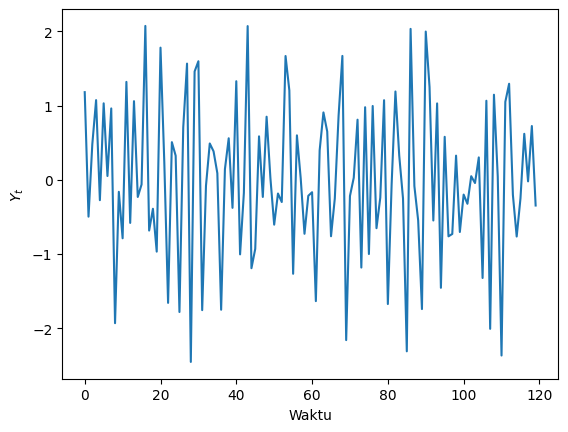

In [ ]:
plt.figure()
plt.plot(ma1)
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.show()

In [ ]:
n = 120
ma1 = pd.DataFrame({
    "Periode": np.arange(1, n + 1),
    "MA1": ma1
})

In [ ]:
ma1.head()

,Periode,MA1
0,1,1.181201
1,2,-0.496763
2,3,0.478514
3,4,1.074014
4,5,-0.274723


In [ ]:
ma1.tail()

,Periode,MA1
115,116,-0.249998
116,117,0.619973
117,118,-0.021011
118,119,0.724783
119,120,-0.346628


## 2. Split Train-Test

In [ ]:
train_size = int(len(ma1) * 0.80)

train = ma1.iloc[:train_size].copy()
test = ma1.iloc[train_size:].copy()

print("Jumlah data keseluruhan :", len(ma1))
print("Jumlah data training   :", len(train))
print("Jumlah data testing    :", len(test))

Jumlah data keseluruhan : 120
Jumlah data training   : 96
Jumlah data testing    : 24


In [ ]:
print("Periode training :", train["Periode"].min(), "-", train["Periode"].max())
print("Periode testing  :", test["Periode"].min(), "-", test["Periode"].max())

Periode training : 1 - 96
Periode testing  : 97 - 120


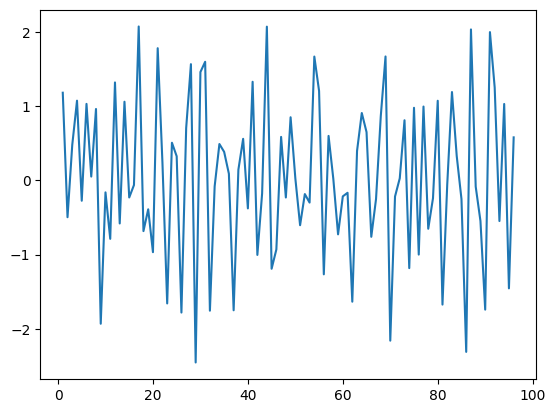

In [ ]:
plt.figure()
plt.plot(train["Periode"],train["MA1"],label="Training")
plt.show()

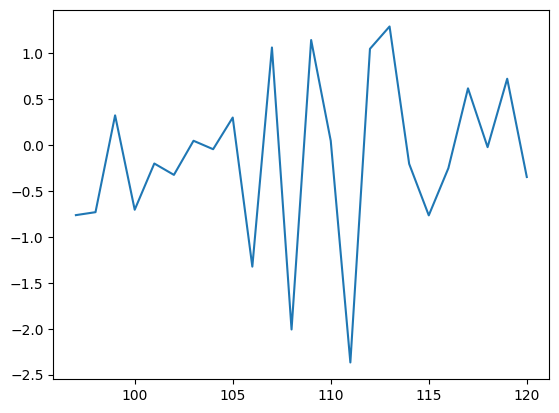

In [ ]:
plt.figure()
plt.plot(test["Periode"],test["MA1"],label="Testing")
plt.show()

In [ ]:
train_data = train["MA1"]
print("Jumlah data training:", len(train_data))
print(train_data.head())

Jumlah data training: 96
0    1.181201
1   -0.496763
2    0.478514
3    1.074014
4   -0.274723
Name: MA1, dtype: float64


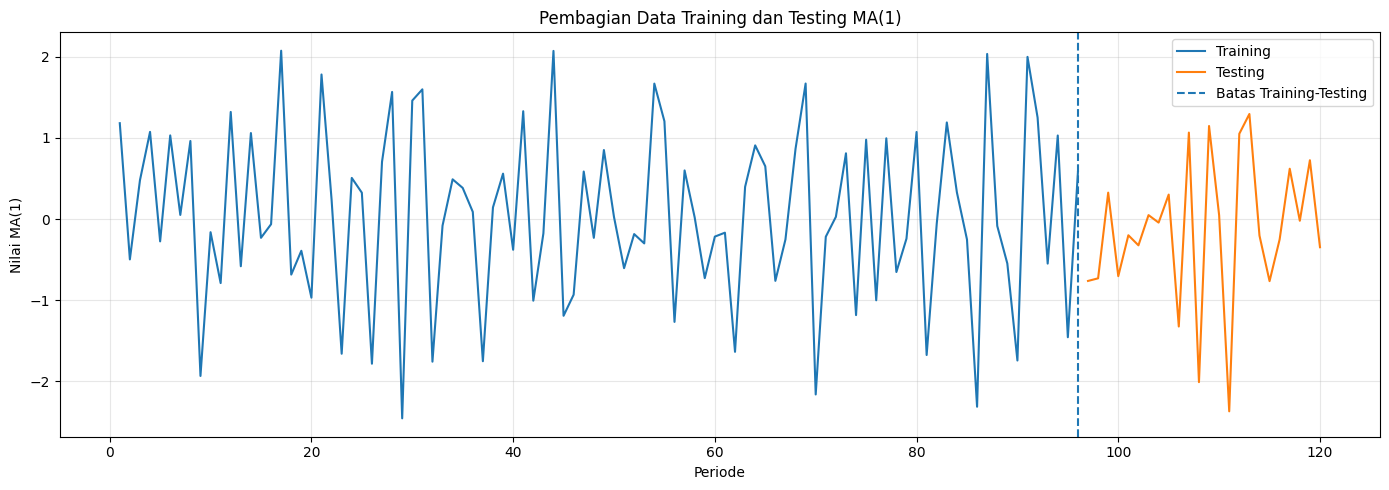

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Data training
plt.plot(
    train["Periode"],
    train["MA1"],
    label="Training"
)

# Data testing
plt.plot(
    test["Periode"],
    test["MA1"],
    label="Testing"
)

# Garis batas training dan testing
plt.axvline(
    x=train["Periode"].iloc[-1],
    linestyle="--",
    label="Batas Training-Testing"
)

plt.title("Pembagian Data Training dan Testing MA(1)")
plt.xlabel("Periode")
plt.ylabel("Nilai MA(1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. PLOT ACF, PACF, EACF

Plot ACF

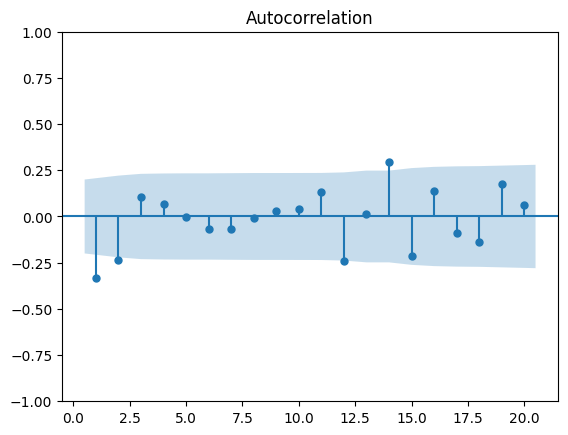

In [ ]:
plot_acf(np.array(train_data), zero=False)
plt.show()

Plot PACF

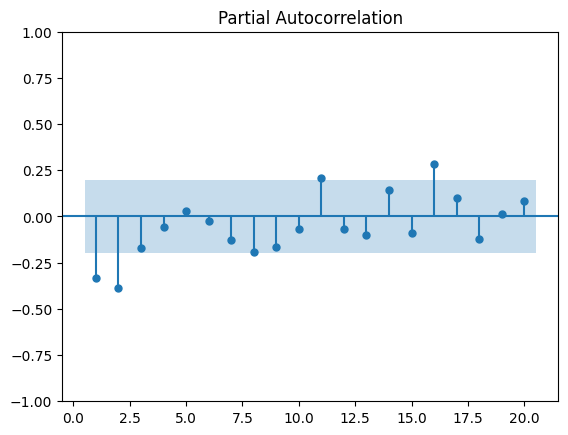

In [ ]:
plot_pacf(np.array(train_data), zero=False)
plt.show()

EACF

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf
from statsmodels.regression.linear_model import yule_walker

In [ ]:
def eacf_tsa(data, ar_max=5, ma_max=5):

    z = np.asarray(data, dtype=float)
    z = z - np.mean(z)

    n = len(z)

    eacf_values = np.zeros(
        (ar_max + 1, ma_max + 1)
    )

    # Hitung EACF untuk setiap kombinasi p dan q
    for p in range(ar_max + 1):

        # p = 0
        if p == 0:
            residual = z

        else:
            # Membuat lag
            df = pd.DataFrame({
                "y": z
            })

            for lag in range(1, p + 1):
                df[f"lag{lag}"] = df["y"].shift(lag)

            df = df.dropna()

            y = df["y"].values

            X = df[
                [f"lag{lag}" for lag in range(1, p + 1)]
            ].values

            # Estimasi AR(p) menggunakan Yule-Walker
            rho, sigma = yule_walker(
                z,
                order=p,
                method="adjusted"
            )

            # Residual AR(p)
            residual = np.zeros(
                len(z) - p
            )

            for t in range(p, len(z)):

                prediction = np.sum(
                    rho * z[
                        t - np.arange(1, p + 1)
                    ]
                )

                residual[t - p] = (
                    z[t] - prediction
                )

        # ACF residual
        acf_residual = acf(
            residual,
            nlags=ma_max,
            fft=False
        )

        for q in range(ma_max + 1):

            eacf_values[p, q] = acf_residual[q]

    # Batas signifikansi
    critical_value = 1.96 / np.sqrt(n)

    # Membuat simbol x/o
    eacf_symbols = np.empty(
        eacf_values.shape,
        dtype=object
    )

    for i in range(eacf_values.shape[0]):

        for j in range(eacf_values.shape[1]):

            if abs(eacf_values[i, j]) > critical_value:
                eacf_symbols[i, j] = "x"
            else:
                eacf_symbols[i, j] = "o"

    return eacf_values, eacf_symbols

In [ ]:
eacf_values, eacf_symbols = eacf_tsa(
    train_data,
    ar_max=5,
    ma_max=5
)

In [ ]:
eacf_table = pd.DataFrame(
    eacf_symbols,
    index=[f"AR({p})" for p in range(6)],
    columns=[f"MA({q})" for q in range(6)]
)

display(eacf_table)

,MA(0),MA(1),MA(2),MA(3),MA(4),MA(5)
AR(0),x,x,x,o,o,o
AR(1),x,o,x,o,o,o
AR(2),x,o,o,o,o,o
AR(3),x,o,o,o,o,o
AR(4),x,o,o,o,o,o
AR(5),x,o,o,o,o,o


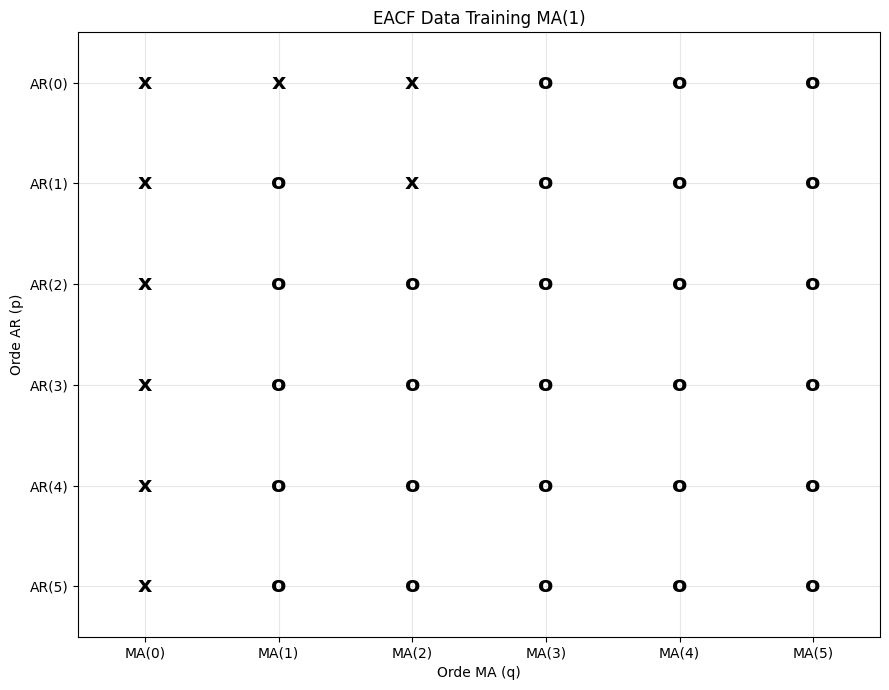

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

for i in range(eacf_symbols.shape[0]):
    for j in range(eacf_symbols.shape[1]):

        ax.text(
            j,
            i,
            eacf_symbols[i, j],
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold"
        )

ax.set_xticks(range(6))
ax.set_xticklabels(
    [f"MA({q})" for q in range(6)]
)

ax.set_yticks(range(6))
ax.set_yticklabels(
    [f"AR({p})" for p in range(6)]
)

ax.set_xlabel("Orde MA (q)")
ax.set_ylabel("Orde AR (p)")

ax.set_title(
    "EACF Data Training MA(1)"
)

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(5.5, -0.5)

ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

ax.set_xlabel("Orde MA (q)")
ax.set_ylabel("Orde AR (p)")
ax.set_title("EACF Data Training MA(1)")

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(4.5, -0.5)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Fit Model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_ma1 = ARIMA(
    train_data,
    order=(0, 0, 1)
)

fit_ma1 = model_ma1.fit()

print(fit_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                    MA1   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -129.846
Date:                Wed, 23 Sep 2026   AIC                            265.691
Time:                        03:41:28   BIC                            273.384
Sample:                             0   HQIC                           268.801
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0290      0.027      1.078      0.281      -0.024       0.082
ma.L1         -0.7249      0.083     -8.686      0.000      -0.888      -0.561
sigma2         0.8689      0.132      6.563      0.0

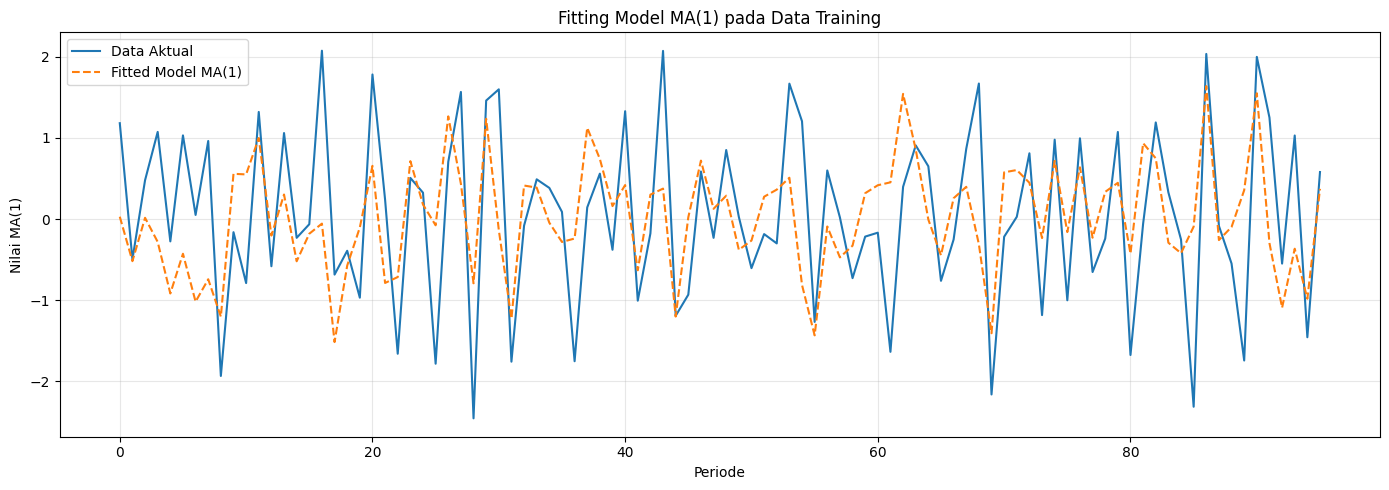

In [ ]:
import matplotlib.pyplot as plt

# Fitted value dari model MA(1)
fitted_ma1 = fit_ma1.fittedvalues

plt.figure(figsize=(14, 5))

# Data aktual
plt.plot(
    train_data.index,
    train_data,
    label="Data Aktual"
)

# Fitted model MA(1)
plt.plot(
    fitted_ma1.index,
    fitted_ma1,
    linestyle="--",
    label="Fitted Model MA(1)"
)

plt.title("Fitting Model MA(1) pada Data Training")
plt.xlabel("Periode")
plt.ylabel("Nilai MA(1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Diagnostik Sisaan Model, Overfitting, dan AIC & BIC

Diagnostik sisaan model

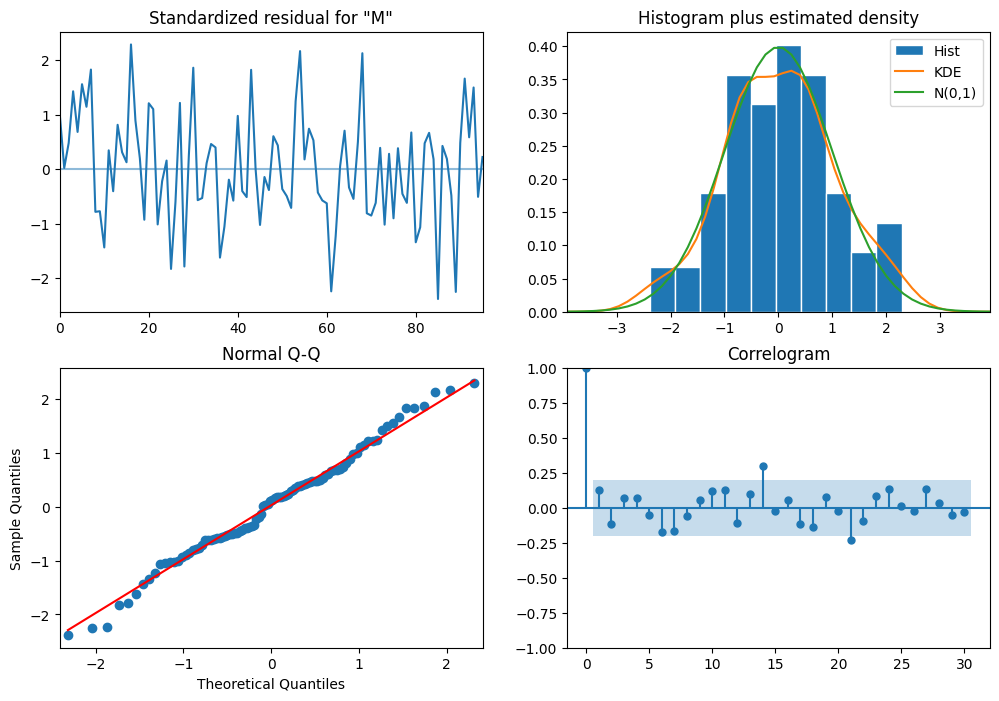

In [ ]:
fit_ma1.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, jarque_bera
from statsmodels.stats.diagnostic import het_arch
from statsmodels.sandbox.stats.runs import runstest_1samp

# Residual model MA(1)
residual_ma1 = fit_ma1.resid

# =========================
# 1. Breakvar Test
# =========================
breakvar_stat, breakvar_p = fit_ma1.test_heteroskedasticity('breakvar')[0]

# =========================
# 2. ARCH Test
# =========================
arch_stat, arch_p = het_arch(residual_ma1, nlags=30)[0], het_arch(residual_ma1, nlags=30)[1]

# =========================
# 3. Runs Test
# =========================
runs_stat, runs_p = runstest_1samp(
    residual_ma1,
    correction=False
)

# =========================
# 4. Shapiro-Wilk Test
# =========================
shapiro_stat, shapiro_p = shapiro(residual_ma1)

# =========================
# 5. Jarque-Bera Test
# =========================
jb_stat, jb_p = jarque_bera(residual_ma1)

# =========================
# Membuat tabel
# =========================
hasil_uji = pd.DataFrame({
    "Uji Diagnostik": [
        "Breakvar",
        "ARCH",
        "Runs Test",
        "Shapiro-Wilk",
        "Jarque-Bera"
    ],
    "Statistik": [
        breakvar_stat,
        arch_stat,
        runs_stat,
        shapiro_stat,
        jb_stat
    ],
    "p-value": [
        breakvar_p,
        arch_p,
        runs_p,
        shapiro_p,
        jb_p
    ]
})

# Keputusan berdasarkan α = 5%
hasil_uji["Keputusan (α = 5%)"] = np.where(
    hasil_uji["p-value"] > 0.05,
    "Tidak Tolak H0",
    "Tolak H0"
)

# Pembulatan
hasil_uji["Statistik"] = hasil_uji["Statistik"].round(4)
hasil_uji["p-value"] = hasil_uji["p-value"].round(4)

display(hasil_uji)

,Uji Diagnostik,Statistik,p-value,Keputusan (α = 5%)
0,Breakvar,0.8259,0.5916,Tidak Tolak H0
1,ARCH,23.8658,0.7781,Tidak Tolak H0
2,Runs Test,-0.8051,0.4207,Tidak Tolak H0
3,Shapiro-Wilk,0.9880,0.5372,Tidak Tolak H0
4,Jarque-Bera,0.1370,0.9338,Tidak Tolak H0


In [ ]:
aic_ma1 = fit_ma1.aic
bic_ma1 = fit_ma1.bic

tabel_aic_bic = pd.DataFrame({
    "Model": ["MA(1)"],
    "AIC": [fit_ma1.aic],
    "BIC": [fit_ma1.bic]
})

display(tabel_aic_bic.round(4))

,Model,AIC,BIC
0,MA(1),265.691,273.3841


## 5. Forecasting

MAPE dan RMSE

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# =========================
# 1. Prediksi/Fitted Value Data Latih
# =========================
fitted_train = fit_ma1.fittedvalues

# Samakan index
actual_train = train_data.loc[fitted_train.index]


# =========================
# 2. Forecast Data Uji
# =========================
forecast_test = fit_ma1.forecast(steps=len(test))

# Samakan index dengan data testing
forecast_test = pd.Series(
    forecast_test,
    index=test.index
)

actual_test = test["MA1"]


# =========================
# 3. Fungsi MAPE
# =========================
def mape(y_actual, y_pred):
    y_actual = np.asarray(y_actual)
    y_pred = np.asarray(y_pred)

    # Menghindari pembagian dengan nol
    mask = y_actual != 0

    return np.mean(
        np.abs(
            (y_actual[mask] - y_pred[mask]) /
            y_actual[mask]
        )
    ) * 100


# =========================
# 4. RMSE Data Latih
# =========================
rmse_train = np.sqrt(
    mean_squared_error(
        actual_train,
        fitted_train
    )
)

mape_train = mape(
    actual_train,
    fitted_train
)


# =========================
# 5. RMSE Data Uji
# =========================
rmse_test = np.sqrt(
    mean_squared_error(
        actual_test,
        forecast_test
    )
)

mape_test = mape(
    actual_test,
    forecast_test
)


# =========================
# 6. Tabel Hasil
# =========================
hasil_evaluasi = pd.DataFrame({
    "Data": ["Training", "Testing"],
    "MAPE (%)": [
        mape_train,
        mape_test
    ],
    "RMSE": [
        rmse_train,
        rmse_test
    ]
})

hasil_evaluasi["MAPE (%)"] = hasil_evaluasi["MAPE (%)"].round(4)
hasil_evaluasi["RMSE"] = hasil_evaluasi["RMSE"].round(4)

display(hasil_evaluasi)

,Data,MAPE (%),RMSE
0,Training,219.0956,0.9354
1,Testing,104.3897,0.9198


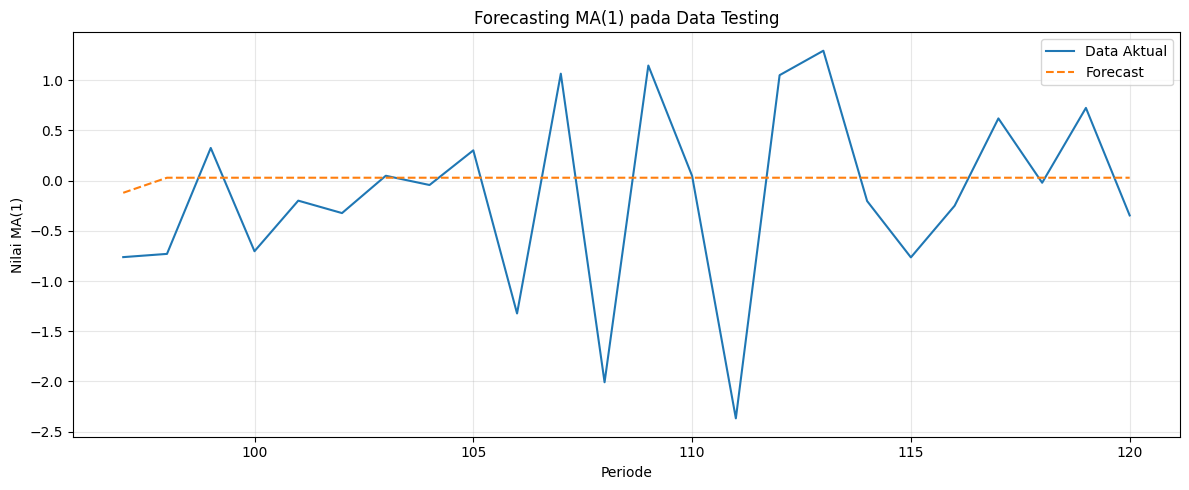

In [ ]:
plt.figure(figsize=(12, 5))

# Data aktual testing
plt.plot(
    test["Periode"],
    test["MA1"],
    label="Data Aktual"
)

# Hasil forecasting
plt.plot(
    test["Periode"],
    forecast_test,
    linestyle="--",
    label="Forecast"
)

plt.title("Forecasting MA(1) pada Data Testing")
plt.xlabel("Periode")
plt.ylabel("Nilai MA(1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

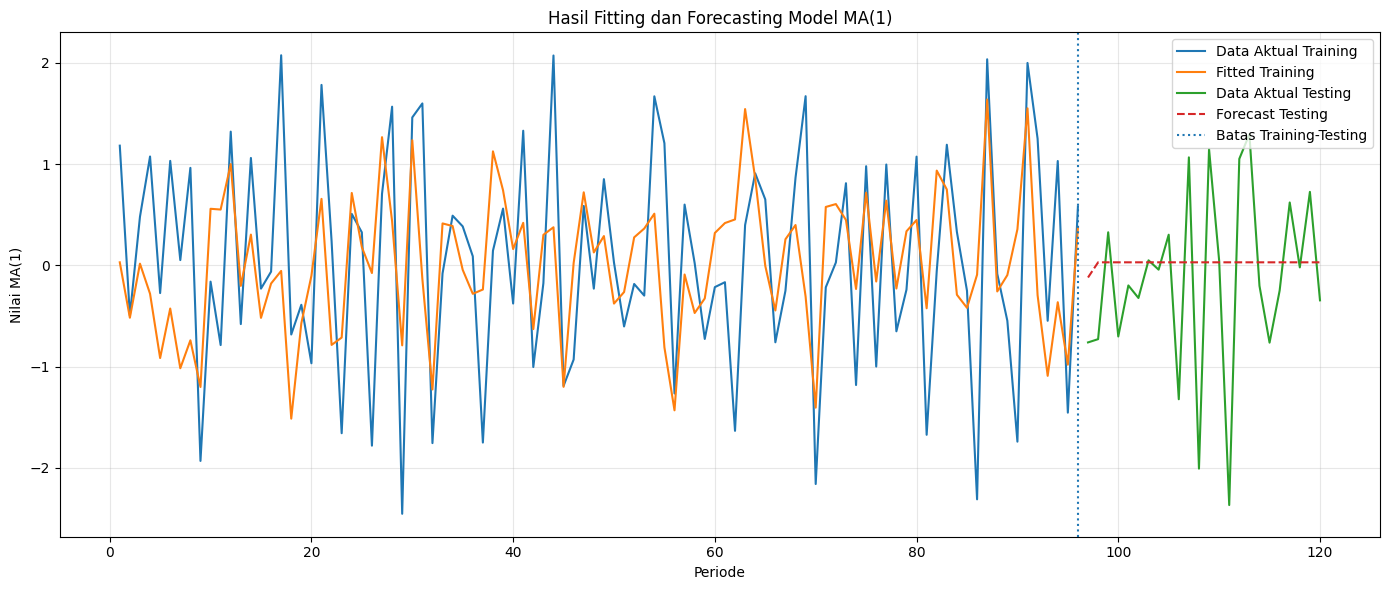

In [ ]:
plt.figure(figsize=(14, 6))

# Data aktual training
plt.plot(
    train["Periode"],
    train["MA1"],
    label="Data Aktual Training"
)

# Fitted value training
plt.plot(
    train["Periode"],
    fitted_train,
    label="Fitted Training"
)

# Data aktual testing
plt.plot(
    test["Periode"],
    test["MA1"],
    label="Data Aktual Testing"
)

# Forecast testing
plt.plot(
    test["Periode"],
    forecast_test,
    linestyle="--",
    label="Forecast Testing"
)

# Garis batas training-testing
plt.axvline(
    x=train["Periode"].iloc[-1],
    linestyle=":",
    label="Batas Training-Testing"
)

plt.title("Hasil Fitting dan Forecasting Model MA(1)")
plt.xlabel("Periode")
plt.ylabel("Nilai MA(1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AR(2)

Proses AR (2) memiliki persamaan:

<center> $Y_t=\phi_1 Y_{t-1}+\phi_2 Y_{t-2}+e_t$ </center>

**Syarat kestasioneran untuk deret AR (2) adalah jika dan hanya jika tiga kondisi berikut terpenuhi, yaitu:**

**<center> $\phi_1+\phi_2<1$  ,   $\phi_2-\phi_1<1$ ,   $|\phi_2|<1$ </center>**


Untuk $\phi_1=0.9$ dan $\phi_2=-0.5$

Dengan $n = 100$

# 1. Bangkitkan Data dengan AR(2)

In [ ]:
np.random.seed(13)
phi1_AR2_1, phi2_AR2_1 = 0.9, -0.5

ar_params_1 = np.array([1, -phi1_AR2_1, -phi2_AR2_1]) #nilai parameter theta dalam sintaks dituliskan sebagai negatif dari nilai parameter asli
ma_params_1 = np.array([1])

AR_object2_1 = ArmaProcess(ar_params_1, ma_params_1)
AR2_s_1 = AR_object2_1.generate_sample(nsample=100)

# Menampilkan 5 data pertama
AR2_df = pd.DataFrame({
    'Waktu': np.arange(1, 101),
    'Y_t': AR2_s_1
})

AR2_df.head()

,Waktu,Y_t
0,1,-0.712391
1,2,0.112615
2,3,0.413046
3,4,0.767246
4,5,1.829100


## Plot AR(2)

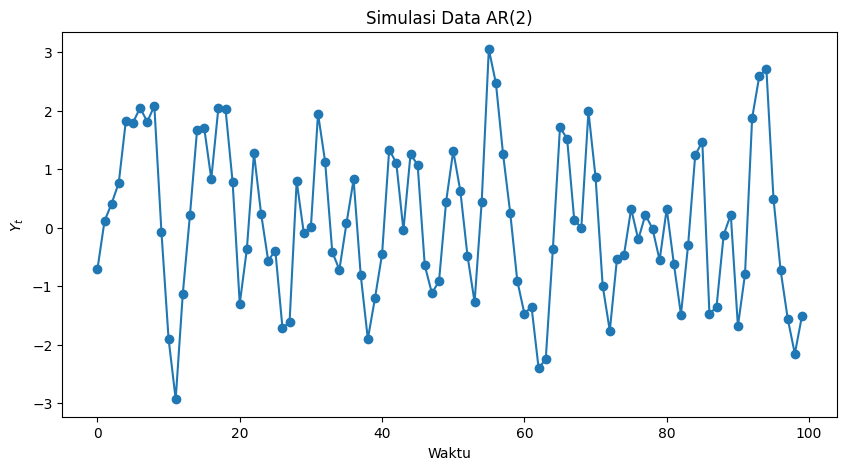

In [ ]:
# Plot Deret Simulasi AR(2)
plt.figure(figsize=(10,5))
plt.plot(AR2_s_1,'-o')
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.title(f'Simulasi Data AR(2)')
plt.show()

# 2. Pembagian Data Training dan Testing

In [ ]:
# Membagi data menjadi 80 data latih dan 20 data uji
n_train = int(0.8 * len(AR2_s_1))

train_AR2 = AR2_s_1[:n_train]
test_AR2  = AR2_s_1[n_train:]

In [ ]:
# melihat beberapa datanya
print("5 data pertama data latih:")
print(train_AR2[:5])

print("\n5 data pertama data uji:")
print(test_AR2[:5])

5 data pertama data latih:
[-0.71239066  0.11261478  0.41304556  0.76724595  1.82910028]

5 data pertama data uji:
[ 0.3240125  -0.61654774 -1.48552624 -0.29953427  1.23909332]


# 3. Plot ACF, PACF dan EACF

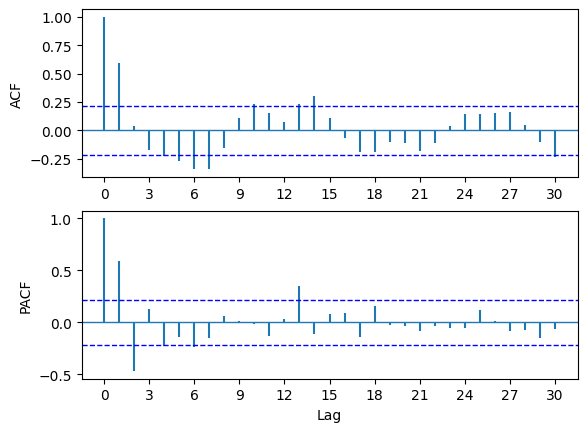

In [ ]:
#plot acf dan pacf
acf_pacf_fig(train_AR2, both=True, lag=30); plt.show()

In [ ]:
!pip install rpy2

In [ ]:
import warnings
warnings.filterwarnings("ignore")

#Jalankan syntax ini cukup satu kali, jangan berulang
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages('TSA')
library (TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’, ‘leaps’, ‘locfit’, ‘tseries’

trying URL 'https://cran.rstudio.com/src/contrib/xts_0.14.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TTR_0.24.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quadprog_1.5-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.9-0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quantmod_0.4.29.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/leaps_3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/locfit_1.5-9.12.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tseries_0.10-63.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpPvhDhX/downloaded_packages’

Attaching package: ‘TSA’

The following objects are masked from ‘package:stats’:

    acf, arima

The f

In [ ]:
%%R -i train_AR2
#membuat plot EACF dari data Train AR(2)
eacf(as.numeric(train_AR2))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o x x x o o o o  o  o  x 
1 x o o o o o x o o o o  o  o  x 
2 x x o o o o o o o o o  o  o  x 
3 x x o o o o o o o o o  o  o  x 
4 x o o o o o o o o o o  o  o  x 
5 x x o o o o o o o o o  o  o  x 
6 x o x x x o o o o o o  o  o  o 
7 x o o x o o o o o o o  o  o  o 


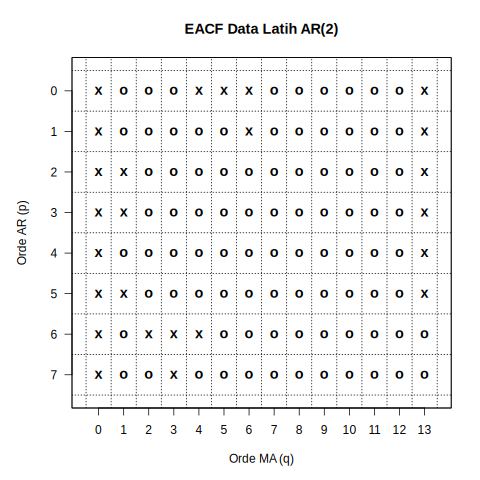

In [ ]:
%%R -i train_AR2

library(TSA)

# Menghitung EACF tanpa menampilkan tabel
invisible(
  capture.output(
    hasil_eacf <- eacf(as.numeric(train_AR2))
  )
)

# Mengambil matriks simbol EACF
simbol <- hasil_eacf$symbol

n_ar <- nrow(simbol)
n_ma <- ncol(simbol)

# Membuat grafik EACF
par(mar = c(5, 5, 4, 2))

plot(
  NA,
  xlim = c(-0.5, n_ma - 0.5),
  ylim = c(n_ar - 0.5, -0.5),
  xaxt = "n",
  yaxt = "n",
  xlab = "Orde MA (q)",
  ylab = "Orde AR (p)",
  main = "EACF Data Latih AR(2)"
)

# Label sumbu
axis(
  1,
  at = 0:(n_ma - 1),
  labels = 0:(n_ma - 1)
)

axis(
  2,
  at = 0:(n_ar - 1),
  labels = 0:(n_ar - 1),
  las = 1
)

# Membuat grid
abline(
  v = seq(-0.5, n_ma - 0.5, 1),
  h = seq(-0.5, n_ar - 0.5, 1),
  lty = 3
)

# Memasukkan simbol x dan o ke dalam grafik
for (i in 1:n_ar) {
  for (j in 1:n_ma) {

    text(
      x = j - 1,
      y = i - 1,
      labels = simbol[i, j],
      cex = 1.2,
      font = 2
    )

  }
}

box()

## Pengepasan model AR(2)

Karena data simulasi Anda dibentuk dari:

$$Y_t = 0.9Y_{t-1} - 0.5Y_{t-2} + \varepsilon_t$$

lalu dilakukan fitting AR(2) tanpa konstanta.

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -105.893
Date:                Wed, 23 Sep 2026   AIC                            217.785
Time:                        03:48:27   BIC                            224.931
Sample:                             0   HQIC                           220.650
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8770      0.113      7.777      0.000       0.656       1.098
ar.L2         -0.4648      0.099     -4.706      0.000      -0.658      -0.271
sigma2         0.8169      0.142      5.761      0.0

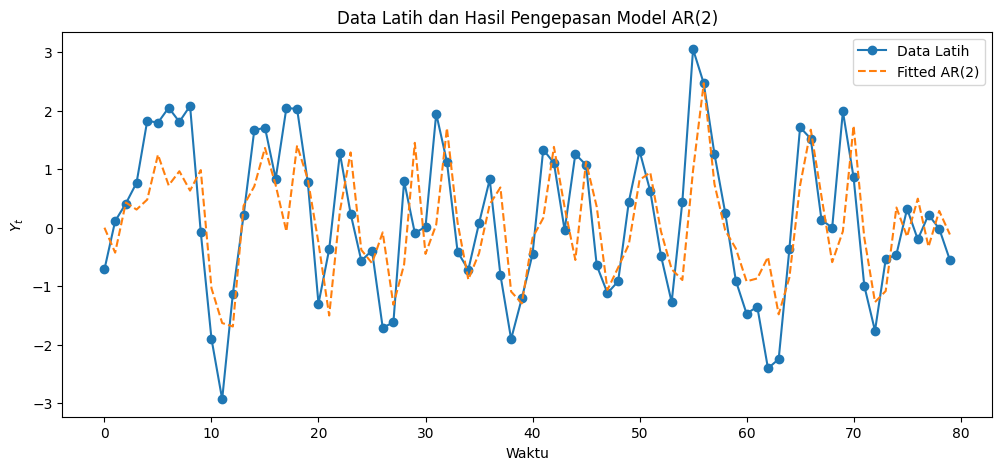

In [ ]:
# Identifikasi dan Pengepasan Model AR(2)

from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Pengepasan model AR(2)
model_AR2 = ARIMA(
    train_AR2,
    order=(2, 0, 0),
    trend='n'
)

fit_AR2 = model_AR2.fit()

# Ringkasan hasil fitting
print(fit_AR2.summary())

# Menampilkan parameter AR
print("\nParameter AR hasil estimasi:")
print("phi1 =", fit_AR2.arparams[0])
print("phi2 =", fit_AR2.arparams[1])

# Membandingkan dengan parameter simulasi
print("\nPerbandingan parameter:")
print("phi1 simulasi = 0.9")
print("phi1 estimasi =", fit_AR2.arparams[0])

print("phi2 simulasi = -0.5")
print("phi2 estimasi =", fit_AR2.arparams[1])

# Plot aktual vs fitted
fitted_AR2 = fit_AR2.fittedvalues

plt.figure(figsize=(12,5))

plt.plot(
    train_AR2,
    label='Data Latih',
    marker='o'
)

plt.plot(
    fitted_AR2,
    label='Fitted AR(2)',
    linestyle='--'
)

plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.title('Data Latih dan Hasil Pengepasan Model AR(2)')
plt.legend()

plt.show()

# 4. Analisis Sisaan Model, Overfitting, dan Model Terbaik

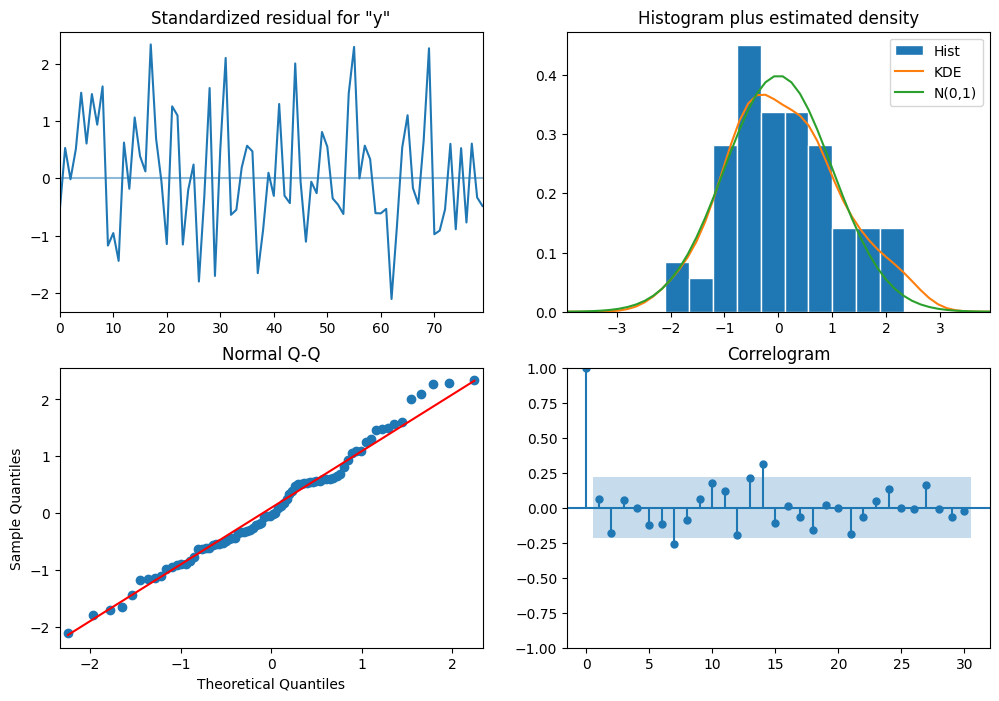

===== UJI HETEROSKEDASTISITAS BREAKVAR =====
Statistik : 0.8905506659313854
p-value   : 0.7654749109973465

===== UJI ARCH-LM =====
Statistik : 26.274182224407916
p-value   : 0.6610659025919707

===== RUNS TEST =====
Statistik : 0.02256068579678549
p-value   : 0.9820007040284789

===== UJI SHAPIRO-WILK =====
Statistik : 0.9825193041434395
p-value   : 0.34485386114666794

===== KRITERIA MODEL AR(2) =====
AIC : 217.7850599172811
BIC : 224.93113982130274


In [ ]:
# ============================================================
# NOMOR 4
# DIAGNOSTIK SISAAN MODEL AR(2)
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_arch
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import shapiro


# ============================================================
# 1. Plot Diagnostik Sisaan
# ============================================================

fit_AR2.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()


# ============================================================
# 2. Uji Heteroskedastisitas - Break Variance
# ============================================================

breakvar = fit_AR2.test_heteroskedasticity('breakvar')

print("===== UJI HETEROSKEDASTISITAS BREAKVAR =====")
print("Statistik :", breakvar[0][0])
print("p-value   :", breakvar[0][1])


# ============================================================
# 3. Uji ARCH-LM
# ============================================================

arch_stat, arch_pvalue, _, _ = het_arch(
    fit_AR2.resid,
    nlags=30
)

print("\n===== UJI ARCH-LM =====")
print("Statistik :", arch_stat)
print("p-value   :", arch_pvalue)


# ============================================================
# 4. Runs Test
# ============================================================

runs_stat, runs_pvalue = runstest_1samp(
    fit_AR2.resid,
    correction=False
)

print("\n===== RUNS TEST =====")
print("Statistik :", runs_stat)
print("p-value   :", runs_pvalue)


# ============================================================
# 5. Uji Normalitas Shapiro-Wilk
# ============================================================

shapiro_stat, shapiro_pvalue = shapiro(
    fit_AR2.resid
)

print("\n===== UJI SHAPIRO-WILK =====")
print("Statistik :", shapiro_stat)
print("p-value   :", shapiro_pvalue)


# ============================================================
# 6. AIC dan BIC Model AR(2)
# ============================================================

print("\n===== KRITERIA MODEL AR(2) =====")
print("AIC :", fit_AR2.aic)
print("BIC :", fit_AR2.bic)

# 5. Forecasting

Jumlah periode forecast : 20

Hasil forecast:
[-4.78822196e-01 -1.62233842e-01  8.02469888e-02  1.45778237e-01
  9.05587939e-02  1.16733453e-02 -3.18492342e-02 -3.33583068e-02
 -1.44546849e-02  2.82592621e-03  9.19627820e-03  6.75217075e-03
  1.64796162e-03 -1.69274351e-03 -2.25049805e-03 -1.18707768e-03
  4.80327702e-06  5.55907655e-04  4.85321990e-04  1.67289351e-04]


,Data,RMSE,MAPE (%)
0,Data Latih,0.9120,1628.0693
1,Data Uji,1.4507,107.5799


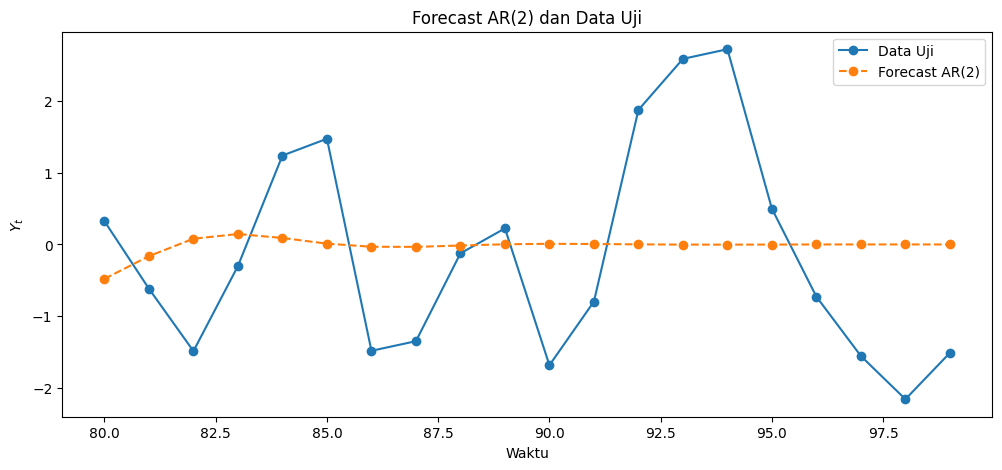

In [ ]:
# ============================================================
# NOMOR 5
# Peramalan dan Evaluasi Model AR(2)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Forecast sepanjang periode data uji
# ============================================================

n_test = len(test_AR2)

forecast_AR2 = fit_AR2.forecast(steps=n_test)

print("Jumlah periode forecast :", n_test)
print("\nHasil forecast:")
print(forecast_AR2)


# ============================================================
# 2. Fitted value untuk data latih
# ============================================================

fitted_AR2 = fit_AR2.fittedvalues

# Karena model AR(2) membutuhkan 2 lag sebelumnya,
# evaluasi data latih dimulai dari observasi ke-3
actual_train = np.asarray(train_AR2)[2:]
pred_train   = np.asarray(fitted_AR2)[2:]


# Data uji
actual_test = np.asarray(test_AR2)
pred_test   = np.asarray(forecast_AR2)


# ============================================================
# 3. Fungsi MAPE
# ============================================================

def hitung_mape(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    # Menghindari pembagian tepat dengan nol
    mask = actual != 0

    return np.mean(
        np.abs(
            (actual[mask] - predicted[mask]) / actual[mask]
        )
    ) * 100


# ============================================================
# 4. RMSE dan MAPE Data Latih
# ============================================================

rmse_train = np.sqrt(
    mean_squared_error(
        actual_train,
        pred_train
    )
)

mape_train = hitung_mape(
    actual_train,
    pred_train
)


# ============================================================
# 5. RMSE dan MAPE Data Uji
# ============================================================

rmse_test = np.sqrt(
    mean_squared_error(
        actual_test,
        pred_test
    )
)

mape_test = hitung_mape(
    actual_test,
    pred_test
)


# ============================================================
# 6. Tabel Evaluasi
# ============================================================

evaluasi_AR2 = pd.DataFrame({
    'Data': [
        'Data Latih',
        'Data Uji'
    ],

    'RMSE': [
        rmse_train,
        rmse_test
    ],

    'MAPE (%)': [
        mape_train,
        mape_test
    ]
})

display(evaluasi_AR2.round(4))


# ============================================================
# 7. Plot Forecast vs Data Uji
# ============================================================

periode_test = np.arange(
    len(train_AR2),
    len(train_AR2) + len(test_AR2)
)

plt.figure(figsize=(12,5))

plt.plot(
    periode_test,
    test_AR2,
    marker='o',
    label='Data Uji'
)

plt.plot(
    periode_test,
    forecast_AR2,
    marker='o',
    linestyle='--',
    label='Forecast AR(2)'
)

plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.title('Forecast AR(2) dan Data Uji')
plt.legend()
plt.show()

<h1> Model Campuran ARMA </h1>

Jika diasumsikan bahwa deret terdiri dari setengah autoregressive dan setengah lagi rataan bergerak, akan diperoleh model deret waktu yang cukup umum dengan persamaan:

<center> $Y_t=\phi_1 Y_{t-1}+\phi_2 Y_{t-2}+...+\phi_p Y_{t-p}+e_t-\theta_1 e_{t-1}-\theta_2 e_{t-2}-...-\theta_q e_{t-q}$ </center>

Dikatakan bahwa $ {Y_t} $merupakan proses campuran autoregressive moving average ordo p dan q, atau disingkat dengan ARMA(p,q).

<h2> ARMA (1,1) </h2>

Persamaan umum untuk proses ARMA (1,1) adalah:

<center> $Y_t=\phi Y_{t-1}+e_t-\theta e_{t-1}$ </center>

Kita simulasikan deret ARMA (1,1) dengan $\phi=0.4$ dan $\theta=0.6$

# 1. Simulasi ARMA(1,1)

In [ ]:
np.random.seed(13)
nsample = 200

AR1 = np.array([1,-0.4]) #nilai parameter phi dalam sintaks dituliskan sebagai negatif dari nilai parameter asli
MA1 = np.array([1,-0.6]) #nilai parameter theta dalam sintaks dituliskan sebagai negatif dari nilai parameter asli
ARMA_OBJECT1 = ArmaProcess(AR1,MA1)
ARMA1 = ARMA_OBJECT1.generate_sample(nsample=200)
ARMA1[:5]

array([-0.71239066,  0.89624451, -0.1382651 ,  0.42320815,  1.24329756])

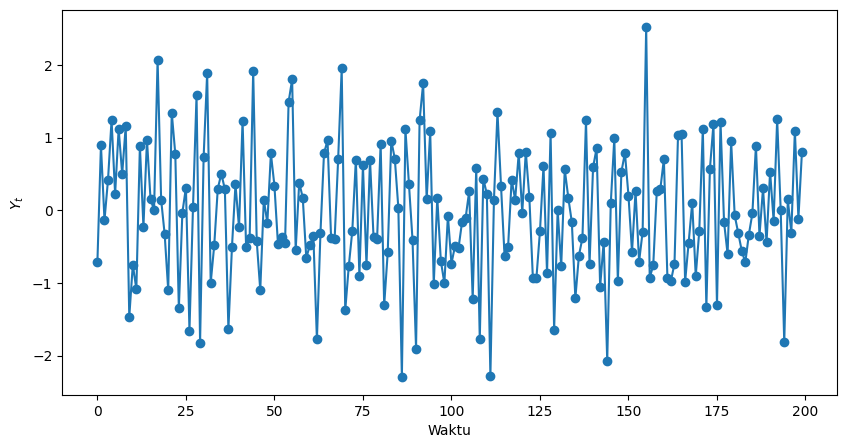

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ARMA1,'-o')
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.show()

# 2. Pembagian Data Latih dan Data Uji


In [ ]:
train_size = int(nsample * 0.8)
train = ARMA1[:train_size]
test = ARMA1[train_size:]

print(f"Jumlah data latih : {len(train)}")
print(f"Jumlah data uji   : {len(test)}")

Jumlah data latih : 160
Jumlah data uji   : 40


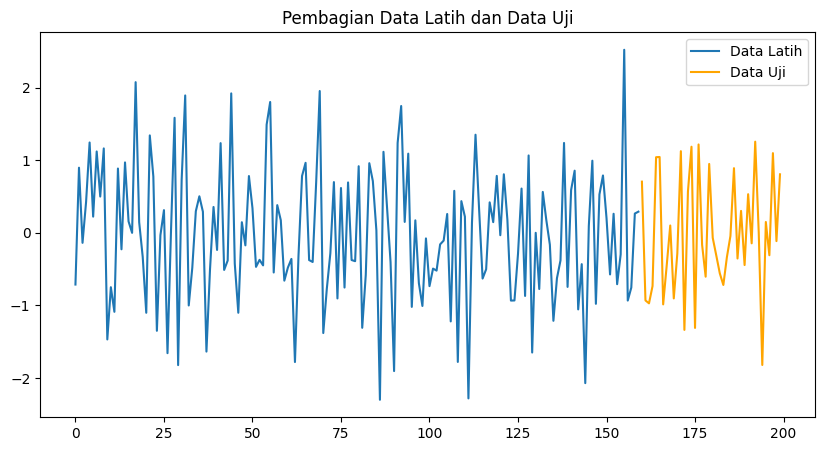

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train)), train, label='Data Latih')
plt.plot(range(len(train),nsample), test, label='Data Uji', color='orange')
plt.legend()
plt.title('Pembagian Data Latih dan Data Uji')
plt.show()

# 3. Plot ACF, PACF, dan EACF dari Data Latih

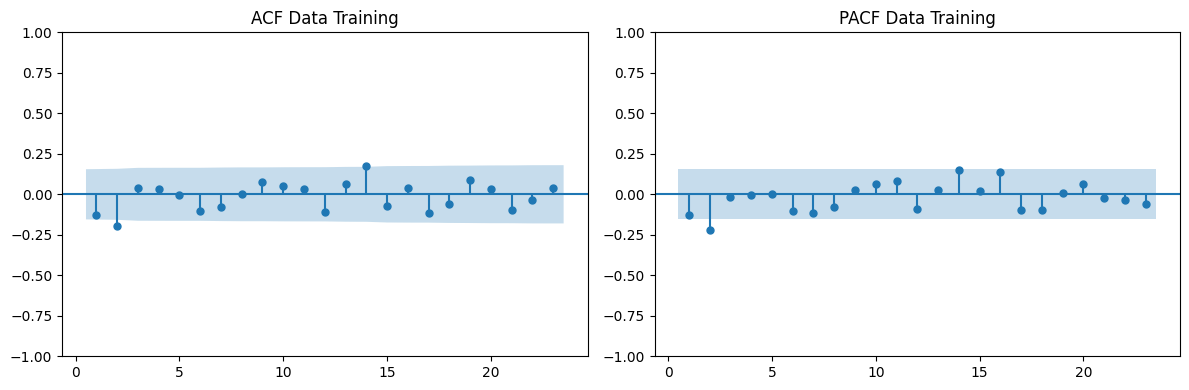

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train, zero=False, ax=axes[0])
axes[0].set_title('ACF Data Training')
plot_pacf(train, zero=False, ax=axes[1])
axes[1].set_title('PACF Data Training')
plt.tight_layout()
plt.show()

In [ ]:
%%R -i train

library(TSA)

# EACF data training
eacf(as.numeric(train))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 o x o o o o o o o o o  o  o  x 
1 x x o o o o o o o o o  o  o  x 
2 o o o o o o o o o o o  o  o  x 
3 x o o o o o o o o o o  o  o  o 
4 x o o x o o o o o o o  o  o  o 
5 o o x o o o o o o o o  o  o  o 
6 x x o o o o o o o o o  o  o  o 
7 x x x o o o o o o o o  o  o  o 


# 4. Diagnostik Sisaan, Overfitting, dan Pemilihan Model Terbaik

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -211.284
Date:                Wed, 23 Sep 2026   AIC                            428.568
Time:                        03:49:17   BIC                            437.793
Sample:                             0   HQIC                           432.314
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5075      0.240      2.119      0.034       0.038       0.977
ma.L1         -0.7042      0.191     -3.688      0.000      -1.078      -0.330
sigma2         0.8208      0.092      8.903      0.0

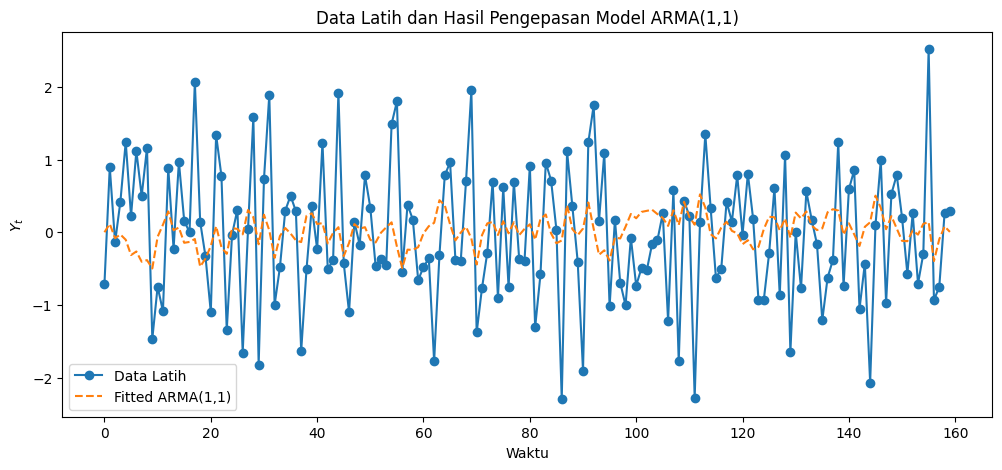

In [ ]:
# Identifikasi dan Pengepasan Model ARMA(1,1)

from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Pengepasan model ARMA(1,1)
model_ARMA11 = ARIMA(
    train,
    order=(1, 0, 1),
    trend='n'
)

fit_ARMA11 = model_ARMA11.fit()

# Ringkasan hasil fitting
print(fit_ARMA11.summary())

# Menampilkan parameter AR dan MA
print("\nParameter AR dan MA hasil estimasi:")
print("phi1 =", fit_ARMA11.arparams[0])
print("theta1 =", fit_ARMA11.maparams[0])

# Plot aktual vs fitted
fitted_ARMA11 = fit_ARMA11.fittedvalues

plt.figure(figsize=(12,5))

plt.plot(
    train,
    label='Data Latih',
    marker='o'
)

plt.plot(
    fitted_ARMA11,
    label='Fitted ARMA(1,1)',
    linestyle='--'
)

plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.title('Data Latih dan Hasil Pengepasan Model ARMA(1,1)')
plt.legend()

plt.show()

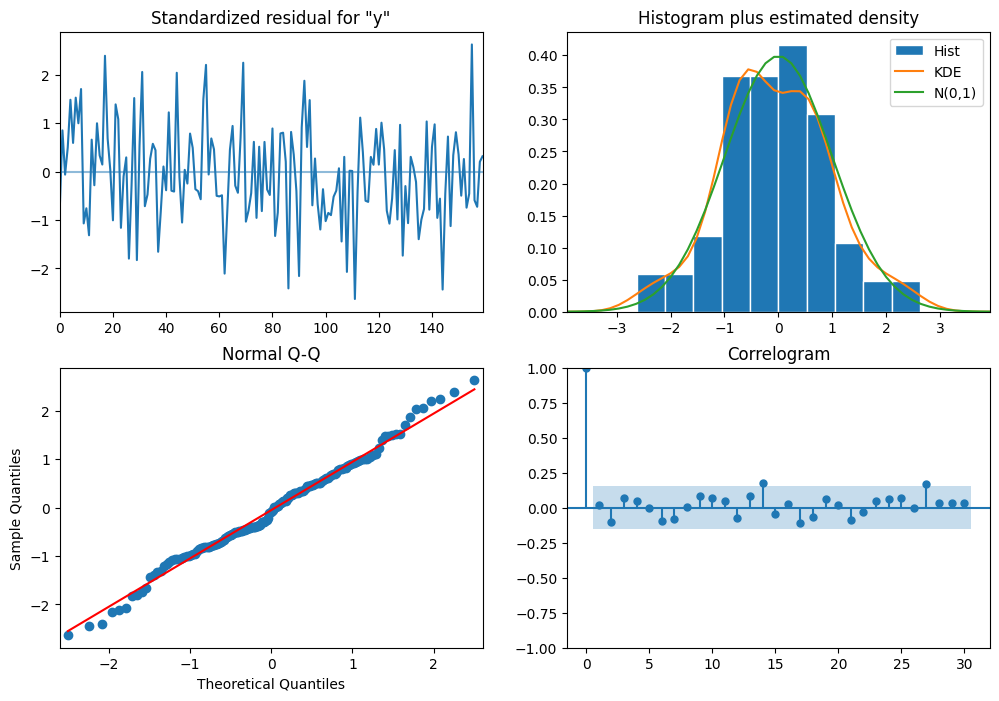

===== UJI HETEROSKEDASTISITAS BREAKVAR =====
Statistik : 0.9252562210742719
p-value   : 0.7783957040918673

===== UJI ARCH-LM =====
Statistik : 22.79080623983236
p-value   : 0.8237611051294991

===== RUNS TEST =====
Statistik : 0.16664894169538946
p-value   : 0.8676462822141279

===== UJI SHAPIRO-WILK =====
Statistik : 0.9908947939119513
p-value   : 0.398438402066735

===== KRITERIA MODEL ARMA(1,1) =====
AIC : 428.56763572322745
BIC : 437.79315716892893


In [ ]:
# ============================================================
# 1. Plot Diagnostik Sisaan
# ============================================================

fit_ARMA11.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()


# ============================================================
# 2. Uji Heteroskedastisitas - Break Variance
# ============================================================

breakvar = fit_ARMA11.test_heteroskedasticity('breakvar')

print("===== UJI HETEROSKEDASTISITAS BREAKVAR =====")
print("Statistik :", breakvar[0][0])
print("p-value   :", breakvar[0][1])


# ============================================================
# 3. Uji ARCH-LM
# ============================================================

arch_stat, arch_pvalue, _, _ = het_arch(
    fit_ARMA11.resid,
    nlags=30
)

print("\n===== UJI ARCH-LM =====")
print("Statistik :", arch_stat)
print("p-value   :", arch_pvalue)


# ============================================================
# 4. Runs Test
# ============================================================

runs_stat, runs_pvalue = runstest_1samp(
    fit_ARMA11.resid,
    correction=False
)

print("\n===== RUNS TEST =====")
print("Statistik :", runs_stat)
print("p-value   :", runs_pvalue)


# ============================================================
# 5. Uji Normalitas Shapiro-Wilk
# ============================================================

shapiro_stat, shapiro_pvalue = shapiro(
    fit_ARMA11.resid
)

print("\n===== UJI SHAPIRO-WILK =====")
print("Statistik :", shapiro_stat)
print("p-value   :", shapiro_pvalue)


# ============================================================
# 6. AIC dan BIC Model ARMA(1,1)
# ============================================================

print("\n===== KRITERIA MODEL ARMA(1,1) =====")
print("AIC :", fit_ARMA11.aic)
print("BIC :", fit_ARMA11.bic)

# 5. Forecasting

Jumlah periode forecast : 40

Hasil forecast:
[-5.39067121e-02 -2.73601477e-02 -1.38865394e-02 -7.04806050e-03
 -3.57721643e-03 -1.81560266e-03 -9.21502256e-04 -4.67704982e-04
 -2.37381893e-04 -1.20482281e-04 -6.11503258e-05 -3.10366164e-05
 -1.57525172e-05 -7.99513046e-06 -4.05789820e-06 -2.05957087e-06
 -1.04532740e-06 -5.30551965e-07 -2.69279642e-07 -1.36671863e-07
 -6.93672866e-08 -3.52071038e-08 -1.78692322e-08 -9.06946119e-09
 -4.60317069e-09 -2.33632186e-09 -1.18579132e-09 -6.01843895e-10
 -3.05463591e-10 -1.55036889e-10 -7.86883862e-11 -3.99379926e-11
 -2.02703770e-11 -1.02881531e-11 -5.22171316e-12 -2.65026075e-12
 -1.34512981e-12 -6.82715544e-13 -3.46509690e-13 -1.75869682e-13]


,Data,RMSE,MAPE (%)
0,Data Latih,0.9062,1869.2678
1,Data Uji,0.8027,100.0712


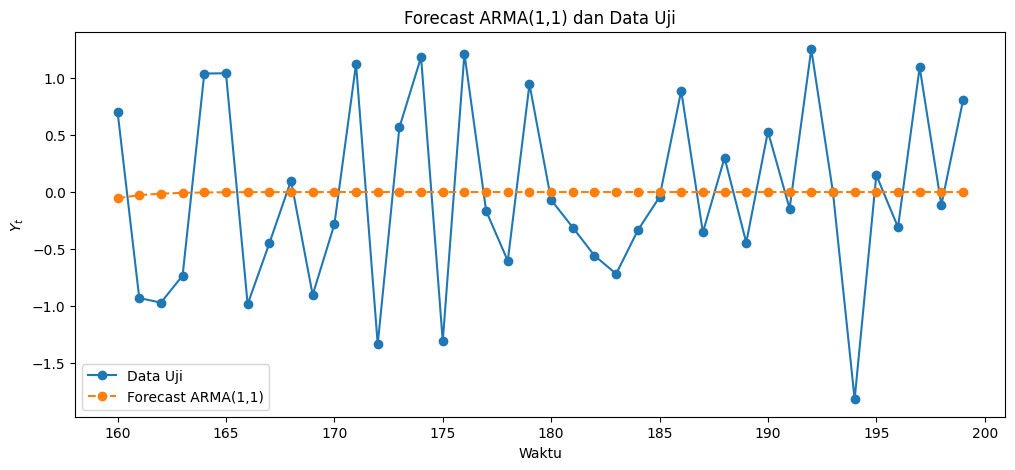

In [ ]:
# ============================================================
# NOMOR 5
# Peramalan dan Evaluasi Model ARMA(1,1)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Forecast sepanjang periode data uji
# ============================================================

n_test = len(test)

forecast_ARMA11 = fit_ARMA11.forecast(steps=n_test)

print("Jumlah periode forecast :", n_test)
print("\nHasil forecast:")
print(forecast_ARMA11)


# ============================================================
# 2. Fitted value untuk data latih
# ============================================================

fitted_ARMA11 = fit_ARMA11.fittedvalues

actual_train = np.asarray(train)
pred_train   = np.asarray(fitted_ARMA11)


# Data uji
actual_test = np.asarray(test)
pred_test   = np.asarray(forecast_ARMA11)


# ============================================================
# 3. Fungsi MAPE
# ============================================================

def hitung_mape(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    # Menghindari pembagian tepat dengan nol
    mask = actual != 0

    return np.mean(
        np.abs(
            (actual[mask] - predicted[mask]) / actual[mask]
        )
    ) * 100


# ============================================================
# 4. RMSE dan MAPE Data Latih
# ============================================================

rmse_train = np.sqrt(
    mean_squared_error(
        actual_train,
        pred_train
    )
)

mape_train = hitung_mape(
    actual_train,
    pred_train
)


# ============================================================
# 5. RMSE dan MAPE Data Uji
# ============================================================

rmse_test = np.sqrt(
    mean_squared_error(
        actual_test,
        pred_test
    )
)

mape_test = hitung_mape(
    actual_test,
    pred_test
)


# ============================================================
# 6. Tabel Evaluasi
# ============================================================

evaluasi_ARMA11 = pd.DataFrame({
    'Data': [
        'Data Latih',
        'Data Uji'
    ],

    'RMSE': [
        rmse_train,
        rmse_test
    ],

    'MAPE (%)': [
        mape_train,
        mape_test
    ]
})

display(evaluasi_ARMA11.round(4))


# ============================================================
# 7. Plot Forecast vs Data Uji
# ============================================================

periode_test = np.arange(
    len(train),
    len(train) + len(test)
)

plt.figure(figsize=(12,5))

plt.plot(
    periode_test,
    test,
    marker='o',
    label='Data Uji'
)

plt.plot(
    periode_test,
    forecast_ARMA11,
    marker='o',
    linestyle='--',
    label='Forecast ARMA(1,1)'
)

plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.title('Forecast ARMA(1,1) dan Data Uji')
plt.legend()
plt.show()